In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

dirName = 'spatialTask_seperated'

cwd = Path.cwd().resolve()
if cwd.name == 'Analysis':
    analysisRoot = cwd
elif cwd.name == 'EconomicDecisionMakingReferenceFrame':
    analysisRoot = cwd / 'Analysis'
elif (cwd / 'EconomicDecisionMakingReferenceFrame' / 'Analysis').exists():
    analysisRoot = cwd / 'EconomicDecisionMakingReferenceFrame' / 'Analysis'
else:
    raise FileNotFoundError('Run this notebook from the repository root or Analysis directory.')
trainingRoot = analysisRoot.parent / 'Training'

savedRoot = trainingRoot / 'savedForLocal'
figureRoot = analysisRoot / 'Figure'
figureRoot.mkdir(parents=True, exist_ok=True)

modelDirs = sorted([
    p for p in (savedRoot / dirName).iterdir()
    if p.is_dir() and (p / 'decodingChoiceSpatial.npz').exists()
])

print('savedRoot:', savedRoot)
print('figureRoot:', figureRoot)
print('n decoded models:', len(modelDirs))
if modelDirs:
    print('example:', modelDirs[0])


savedRoot: D:\NYUSH\DURF_project\EconomicDecisionMakingReferenceFrame\Training\savedForLocal
figureRoot: D:\NYUSH\DURF_project\EconomicDecisionMakingReferenceFrame\Analysis\Figure
n decoded models: 40
example: D:\NYUSH\DURF_project\EconomicDecisionMakingReferenceFrame\Training\savedForLocal\spatialTask_seperated\spatialTaskSeperated_20260715-02-07_0_


In [2]:
def loadDecodingChoiceSpatial(dirPath):
    with np.load(Path(dirPath) / 'decodingChoiceSpatial.npz', allow_pickle=True) as f:
        accuracyLR = f['accuracyLR'].mean(axis=1)
        accuracyAB = f['accuracyAB'].mean(axis=1)
        accuracy12 = f['accuracy12'].mean(axis=1)
        time = f['time'] if 'time' in f else np.arange(len(accuracyLR)) * 10
        target_window = tuple(f['target_window']) if 'target_window' in f else (2500, 3000)
        response_window = tuple(f['response_window']) if 'response_window' in f else (3000, 3200)
    return accuracyLR, accuracyAB, accuracy12, time, target_window, response_window


def decorateSpatialDecodingPlot(ymin=.4, ymax=1):
    plt.fill_between([500, 1000], ymin, ymax, color='gold', alpha=0.25, edgecolor=None, label='_nolegend_')
    plt.fill_between([1500, 2000], ymin, ymax, color='gold', alpha=0.25, edgecolor=None, label='_nolegend_')
    plt.fill_between([2500, 3000], ymin, ymax, color='cadetblue', alpha=0.25, edgecolor=None, label='_nolegend_')
    plt.fill_between([3000, 3200], ymin, ymax, color='plum', alpha=0.25, edgecolor=None, label='_nolegend_')
    plt.xlabel('time (ms)')
    plt.ylabel('decoding accuracy')
    plt.ylim(ymin, ymax)


def plotDecodingChoiceSpatial(dirPath, savePath=None):
    accuracyLR, accuracyAB, accuracy12, time, target_window, response_window = loadDecodingChoiceSpatial(dirPath)
    ymin = .4
    ymax = 1
    fig = plt.figure(dpi=150, figsize=(4, 3))
    decorateSpatialDecodingPlot(ymin, ymax)
    plt.plot(time, accuracyLR, label='chosen side')
    plt.plot(time, accuracyAB, label='chosen juice')
    plt.plot(time, accuracy12, label='chosen order')
    plt.legend(frameon=False)
    plt.title(Path(dirPath).name, fontsize=8)
    plt.tight_layout()
    if savePath is not None:
        fig.savefig(savePath)
    return fig


saved: D:\NYUSH\DURF_project\EconomicDecisionMakingReferenceFrame\Analysis\Figure\decoding_accuracy_seperated_single.pdf


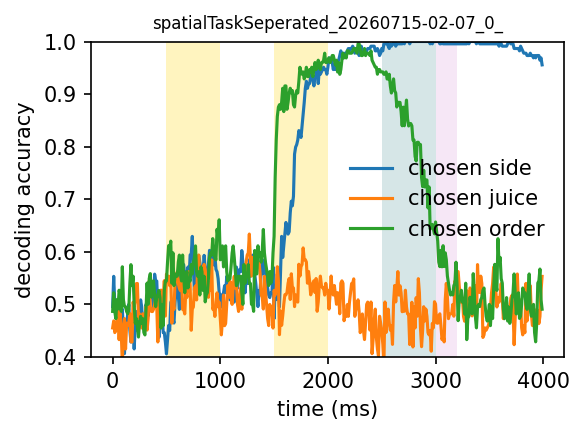

In [3]:
if not modelDirs:
    raise FileNotFoundError('No decodingChoiceSpatial.npz files found. Run test_decoding_choice_seperated.py first.')

dirPathSpatial = modelDirs[0]
singleFigurePath = figureRoot / 'decoding_accuracy_seperated_single.pdf'
fig = plotDecodingChoiceSpatial(dirPathSpatial, singleFigurePath)
print('saved:', singleFigurePath)


saved: D:\NYUSH\DURF_project\EconomicDecisionMakingReferenceFrame\Analysis\Figure\decoding_accuracy_seperated_average.pdf


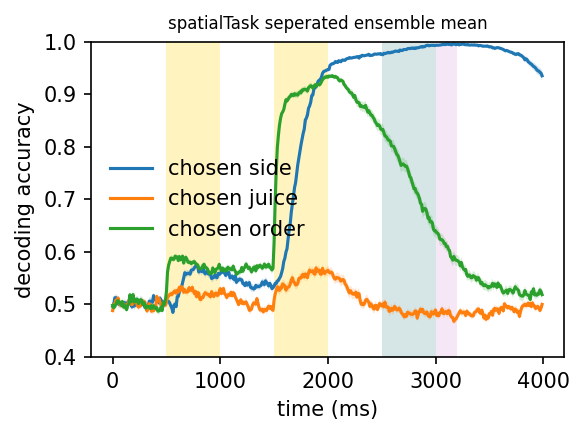

In [4]:
def plotAverageDecodingChoiceSpatial(modelDirs, savePath=None):
    accuracyLRAll = []
    accuracyABAll = []
    accuracy12All = []
    time = None
    for dirPath in modelDirs:
        accuracyLR, accuracyAB, accuracy12, time, target_window, response_window = loadDecodingChoiceSpatial(dirPath)
        accuracyLRAll.append(accuracyLR)
        accuracyABAll.append(accuracyAB)
        accuracy12All.append(accuracy12)

    accuracyLRAll = np.vstack(accuracyLRAll)
    accuracyABAll = np.vstack(accuracyABAll)
    accuracy12All = np.vstack(accuracy12All)

    ymin = .4
    ymax = 1
    fig = plt.figure(dpi=150, figsize=(4, 3))
    decorateSpatialDecodingPlot(ymin, ymax)

    for accuracyAll, label in [
        (accuracyLRAll, 'chosen side'),
        (accuracyABAll, 'chosen juice'),
        (accuracy12All, 'chosen order')]:
        mean = np.nanmean(accuracyAll, axis=0)
        sem = np.nanstd(accuracyAll, axis=0) / np.sqrt(accuracyAll.shape[0])
        plt.plot(time, mean, label=label)
        plt.fill_between(time, mean - sem, mean + sem, alpha=.18, edgecolor=None)

    plt.legend(frameon=False)

    plt.title('spatialTask seperated ensemble mean', fontsize=8)
    plt.tight_layout()
    if savePath is not None:
        fig.savefig(savePath)
    return fig


averageFigurePath = figureRoot / 'decoding_accuracy_seperated_average.pdf'
fig = plotAverageDecodingChoiceSpatial(modelDirs, averageFigurePath)
print('saved:', averageFigurePath)
